## Numerical Analysis - Spring semester 2026
# Serie 03 - Simple linear systems

First, we will need to import some of the usual packages. You will have to run this cell every time you restart your notebook.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib
import timeit
import sys

<hr style="clear:both">

### Simple linear systems

Consider the following two linear systems:

$$
  A_1\mathbf{x} = \mathbf{b}_1, \qquad \text{and} \qquad
  A_1= \begin{bmatrix}
          2 & 4 & 8 \\
          1 & 1 & 4 \\
          3 & 6 & 7
        \end{bmatrix}, \quad
  \mathbf{b}_1 = \begin{bmatrix} 6 \\ 5 \\ 4 \end{bmatrix},
$$

and

$$
  A_2\mathbf{x} = \mathbf{b}_2, \qquad \text{and} \qquad
  A_2 = \begin{bmatrix}
          1 & 1 & 1 & 1 \\
          2 & 2 & 5 & 3 \\
          4 & 6 & 8 & 0 \\
          3 & 3 & 9 & 8
        \end{bmatrix}, \quad
  \mathbf{b}_2 = \begin{bmatrix} 1 \\ 2 \\ 5 \\ 0 \end{bmatrix}.
$$

<div class="alert alert-success">
    
**Exercise 1 (Theoretical):** Solve $A_1 \mathbf{x} = \mathbf{b}_1$ using Gaussian elimination and determine the LU factorization $A_1 = L_1 U_1$.
</div>

=== BEGIN MARK SCHEME ===

Step 1:
\begin{equation*}
\begin{bmatrix}
2 & 4 & 8 & 6\\[1mm]
\frac{1}{2} & -1 & 0 & 2\\[1mm]
\frac{3}{2} & 0 & -5 & -5
\end{bmatrix}.
\end{equation*}
Step 2:
\begin{equation*}
\begin{bmatrix}
2 & 4 & 8 & 6\\[1mm]
\frac{1}{2} & -1 & 0 & 2\\[1mm]
\frac{3}{2} & 0 & -5 & -5
\end{bmatrix}.
\end{equation*}
Thus, $A_1 = L_1 U_1$ with
\begin{align*}
L_1 \coloneqq \begin{bmatrix}
1 & & \\[1mm] \frac{1}{2} & 1 & \\[1mm] \frac{3}{2} & & 1
\end{bmatrix},&&
U_1 \coloneqq \begin{bmatrix}
2 & 4 & 8\\ & -1 & 0\\ & & -5
\end{bmatrix}.
\end{align*}
By back substitution,
\begin{equation*}
\mathbf{x} = U_1^{-1} \begin{bmatrix} 6\\ 2\\ -5 \end{bmatrix} = \begin{bmatrix} 3\\ -2\\ 1 \end{bmatrix}.
\end{equation*}

=== END MARK SCHEME ===

<div class="alert alert-success">
    
**Exercise 2 (Theoretical):** Solve $A_2 \mathbf{x} = \mathbf{b}_2$ using Gaussian elimination with pivoting and determine the LU factorization of $P_2 A_2 = L_2 U_2$.

</div>

=== BEGIN MARK SCHEME ===

Step 1:
- permutation of two rows:
\begin{align*}
\begin{bmatrix}
4 & 6 & 8 & 0 & 5\\ 2 & 2 & 5 & 3 & 2\\ 1 & 1 & 1 & 1 & 1\\ 3 & 3 & 9 & 8 & 0
\end{bmatrix},&&
p \coloneqq \begin{bmatrix} 3\\ 2\\ 1\\ 4\end{bmatrix};
\end{align*}
- Gaussian elimination:
\begin{equation*}
\begin{bmatrix}
4 & 6 & 8 & 0 & 5\\[1mm] \frac{1}{2} & -1 & 1 & 3 & -\frac{1}{2}\\[1mm] \frac{1}{4} & -\frac{1}{2} & -1 & 1 & -\frac{1}{4}\\[1mm] \frac{3}{4} & -\frac{3}{2} & 3 & 8 & -\frac{15}{4}
\end{bmatrix}.
\end{equation*}

Step 2:
- permutation of two rows:
\begin{align*}
\begin{bmatrix}
4 & 6 & 8 & 0 & 5\\[1mm] \frac{3}{4} & -\frac{3}{2} & 3 & 8 & -\frac{15}{4}\\[1mm] \frac{1}{4} & -\frac{1}{2} & -1 & 1 & -\frac{1}{4}\\[1mm] \frac{1}{2} & -1 & 1 & 3 & -\frac{1}{2}
\end{bmatrix},&&
p \coloneqq \begin{bmatrix} 3\\ 4\\ 1\\ 2\end{bmatrix};
\end{align*}
- Gaussian elimination:
\begin{equation*}
\begin{bmatrix}
4 & 6 & 8 & 0 & 5\\[1mm] \frac{3}{4} & -\frac{3}{2} & 3 & 8 & -\frac{15}{4}\\[1mm] \frac{1}{4} & \frac{1}{3} & -2 & -\frac{5}{3} & 1\\[1mm] \frac{1}{2} & \frac{2}{3} & -1 & -\frac{7}{3} & 2
\end{bmatrix}.
\end{equation*}

Step 3:
- permutation of two rows:
\begin{align*}
\begin{bmatrix}
4 & 6 & 8 & 0 & 5\\[1mm] \frac{3}{4} & -\frac{3}{2} & 3 & 8 & -\frac{15}{4}\\[1mm] \frac{1}{4} & \frac{1}{3} & -2 & -\frac{5}{3} & 1\\[1mm] \frac{1}{2} & \frac{2}{3} & -1 & -\frac{7}{3} & 2
\end{bmatrix},&&
p \coloneqq \begin{bmatrix} 3\\ 4\\ 1\\ 2\end{bmatrix};
\end{align*}
- Gaussian elimination:
\begin{equation*}
\begin{bmatrix}
4 & 6 & 8 & 0 & 5\\[1mm] \frac{3}{4} & -\frac{3}{2} & 3 & 8 & -\frac{15}{4}\\[1mm] \frac{1}{4} & \frac{1}{3} & -2 & -\frac{5}{3} & 1\\[1mm] \frac{1}{2} & \frac{2}{3} & \frac{1}{2} & -\frac{3}{2} & \frac{3}{2}
\end{bmatrix}.
\end{equation*}

Thus, $P_2 A_2 = L_2 U_2$ with
\begin{align*}
P_2 \coloneqq \begin{bmatrix}
& & 1 & \\[1mm] & & & 1 \\[1mm] 1 & & & \\[1mm] & 1 & & 
\end{bmatrix},&&
L_2 \coloneqq \begin{bmatrix}
1 & & & \\[1mm] \frac{3}{4} & 1 & & \\[1mm] \frac{1}{4} & \frac{1}{3} & 1 & \\[1mm] \frac{1}{2} & \frac{2}{3} & \frac{1}{2} & 1
\end{bmatrix},&&
U_2 \coloneqq \begin{bmatrix}
4 & 6 & 8 & 0\\[1mm] & -\frac{3}{2} & 3 & 8\\[1mm] & & -2 & -\frac{5}{3}\\[1mm] & & & -\frac{3}{2}
\end{bmatrix}.
\end{align*}
By back substitution,
\begin{equation*}
\mathbf{x} = U_2^{-1} \begin{bmatrix} 5\\[1mm] -\frac{15}{4}\\[1mm] 1\\[1mm] \frac{3}{2} \end{bmatrix} = \begin{bmatrix} \frac{23}{6}\\[1mm] -\frac{13}{6}\\[1mm] \frac{1}{3}\\[1mm] -1 \end{bmatrix}.
\end{equation*}

=== END MARK SCHEME ===

<div class="alert alert-success">
    
**Exercise 3 (Theoretical):** Compute the determinant of the matrix $A_2$ using its LU factorization.

*Hint:* We know that
$$
\text{det}(A_2)=\text{det}(P_2^{-1}L_2U_2)=\displaystyle\frac{\text{det}(L_2) \text{det}(U_2)}{\text{det}(P_2)}.
$$
</div>

=== BEGIN MARK SCHEME ===

We use the relation $\text{det}(A_2)=\text{det}(P_2^{-1}L_2U_2)=\displaystyle\dfrac{1}{\text{det}(P_2)}\text{det}(L_2) \text{det}(U_2)$. Noticing 
that the determinant of a triangular matrix is given by 
the product of its diagonal elements, we find that

$$
  \textrm{det}(A_2) = -1 \cdot 1 \cdot 18 = -18 .
$$

Additionally, note that the determinant of a permutation matrix between two
rows is always $-1$, and therefore the determinant of $P_2$ is $+1$
if we performed an even number of permutations and
$-1$ if we performed an odd number of permutations:
in the case of this exercise, we have $\text{det}(P_2)=-1$.

=== END MARK SCHEME ===

<hr style="clear:both">

### LU factorization for dense and sparse matrix 

<div class="alert alert-success">
    
**Exercise 4:** Complete the function `binomial_matrix` which creates a matrix $A \in \mathbb{R}^{m \times m}$ whose entries $a_{ij}$ for $i,j = 1, 2, \dots, m$ independently follow a binomial distribution with $n \in \mathbb{N}$ trials and a success probability of $p \in [0, 1]$. Use your implementation to create the $(n=10, p=0.5)$-binomial matrix $A \in \mathbb{R}^{400 \times 400}$. Visualize its non-zero entries using the function `plt.spy(A)`, which plots the non-zero entries of a matrix in black.

*Hint:* The NumPy function `np.random.binomial(n, p, (m, m))` outputs an $m \times m$ NumPy array whose entries are independently $(n, p)$-binomial distributed. The seed of NumPy's random number generator is fixed to `seed=0`, such that you will always get the same random matrix for the same parameters.
</div>

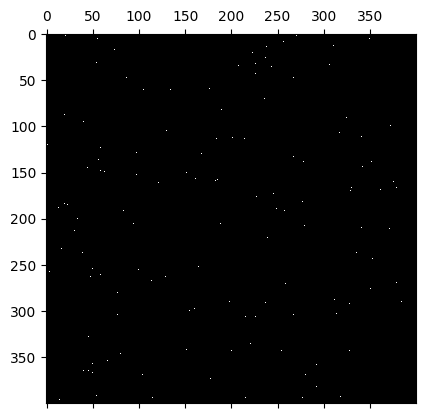

In [2]:
def binomial_matrix(m, n, p, seed=0):
    np.random.seed(seed)
    ### BEGIN SOLUTION
    A = np.random.binomial(n, p, (m, m))
    return A
    ### END SOLUTION

### BEGIN SOLUTION
n = 10
p = 0.5
A = binomial_matrix(400, n, p)
plt.spy(A)
plt.show()
### END SOLUTION

<div class="alert alert-success">
    
**Exercise 5:** Compute the LU factorization using the function `sp.linalg.lu`, which takes as an input a matrix $A$ and returns the three matrices $P$, $L$, and $U$ which characterize the LU factorization of $A$. Visualize the non-zero entries of $L$, $U$, and $P$ (again use `plt.spy`). Have row-permutations been performed? How do the number of non-zero elements in $L$ and $U$ compare with what we saw for $A$?
</div>

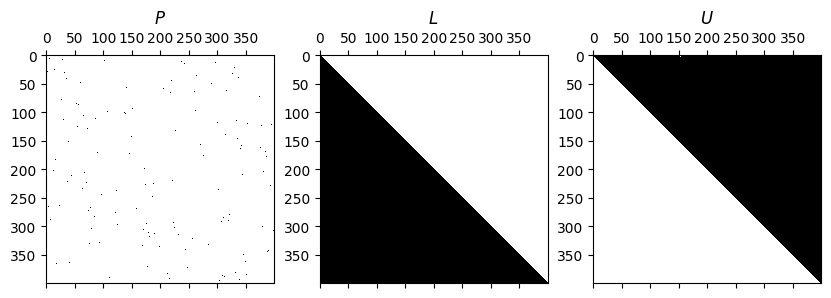

In [3]:
### BEGIN SOLUTION
P, L, U = sp.linalg.lu(A)

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].spy(P)
ax[0].set_title("$P$")
ax[1].spy(L)
ax[1].set_title("$L$")
ax[2].spy(U)
ax[2].set_title("$U$")
plt.show()

# We notice that the matrix P is not the identity matrix, this means that we can be sure
# that at least one permutation was performed. We see that A has almost only non-zero elements
# whereas in L and U, only around half of the elements are non-zero.
# The non-zero structure of L and U displays the triangular patterns typical of LU factorization. 

### END SOLUTION

<div class="alert alert-success">
    
**Exercise 6:** For the binomial matrix $A$ with dimensions $m=20^2, 21^2,\ldots,35^2$, compute the number of non-zero entries $\text{nnz}(A)$ in $A$ and compare it to the number of non-zero elements $\text{nnz}(L) + \text{nnz}(U)$ in its LU factors. Plot the results in a logarithmic plot, and add the number of entries $m^2$ of the full matrix for comparison.

*Hint:* Use `np.count_nonzero` to count the number of non-zero entries in a NumPy array.
</div>

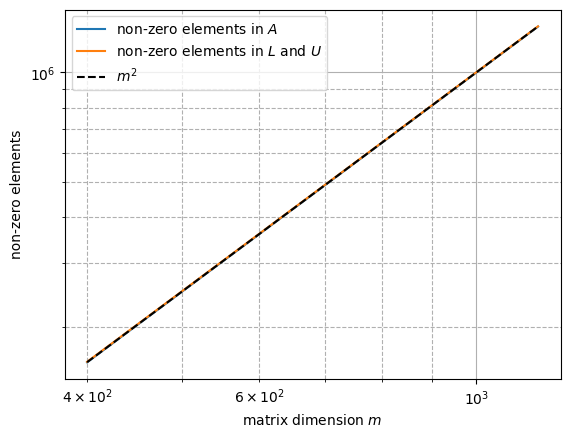

In [4]:
### BEGIN SOLUTION
m_list = np.arange(20, 35) ** 2

nnz_list_A = []
nnz_list_A_LU = []
for m in m_list:
    A = binomial_matrix(m, n, p)
    P, L, U = sp.linalg.lu(A)
    nnz_list_A.append(np.count_nonzero(A))
    nnz_list_A_LU.append(np.count_nonzero(L) + np.count_nonzero(U))

plt.loglog(m_list, nnz_list_A, label="non-zero elements in $A$")
plt.loglog(m_list, nnz_list_A_LU, label="non-zero elements in $L$ and $U$")
plt.loglog(m_list, m_list**2, ls="--", c="k", label="$m^2$")
plt.ylabel("non-zero elements")
plt.xlabel("matrix dimension $m$")
plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="--")
plt.legend()
plt.show()

# Since A is almost a dense matrix, the number of non-zero elements are very close to m².
# Similarly, the number of non-zero elements of both the LU factors together are also approximately m².
### END SOLUTION

Below, we provide you with a function which computes the runtime of the LU factorization algorithm `sp.linalg.lu` for any matrix `A` by executing the function on the matrix multiple times, and averaging the individual runtimes. The number of repetitions of the function execution can be controlled with the argument `repeats`.

In [5]:
def lu_runtime(A, repeats):
    t = timeit.timeit(lambda: sp.linalg.lu(A), number=repeats) / repeats
    return t

<div class="alert alert-success">
    
**Exercise 7:** Measure the approximate runtime for computing the LU factorization of the binomial matrix $A$ of dimensions $m=20^2, 21^2,\ldots,35^2$. Set `repeats=50` to average over $50$ executions of the algorithm to get a more stable estimate of the true run-time.
</div>

<div class="alert alert-info">

**Note:** It may happen that the runtime of the first $m$ is significantly higher. This is due to the caching which Python performes in the background. If it bothers you, you may simply ignore the first $m$.
</div>

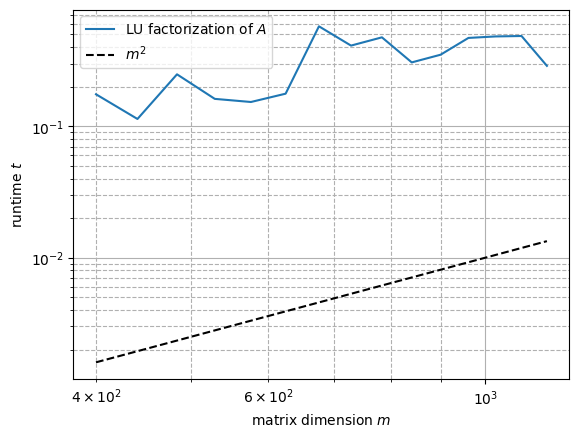

In [6]:
### BEGIN SOLUTION
t_list_A = []
for m in m_list:
    A = binomial_matrix(m, n, p)
    t = lu_runtime(A, repeats=50)
    t_list_A.append(t)

plt.loglog(m_list, t_list_A, label="LU factorization of $A$")
plt.plot(m_list, 1e-8 * m_list ** 2, ls="--", c="k", label="$m^2$")
plt.ylabel("runtime $t$")
plt.xlabel("matrix dimension $m$")
plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="--")
plt.legend()
plt.show()

# We notice that the run-time grows slightly stronger than m²
### END SOLUTION

The following function `laplacian_matrix` generates a Laplacian matrix $B \in \mathbb{R}^{m \times m}$.

In [7]:
def laplacian_matrix(m):
    n = int(np.sqrt(m))
    d = np.ones(n ** 2)
    mat = sp.sparse.spdiags([d, -2 * d, d], [-1, 0, 1], n, n)
    I = sp.sparse.eye(n)
    A = sp.sparse.kron(I, mat) + sp.sparse.kron(mat, I) 
    return A.todense()

<div class="alert alert-success">
    
**Exercise 8:** Repeat all of the above exercises in this section for the Laplacian matrix $B$ with the same dimensions. Compare to the results you've obtained for the binomial matrix $A$.
</div>

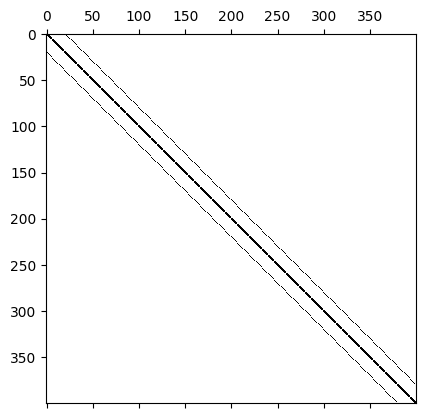

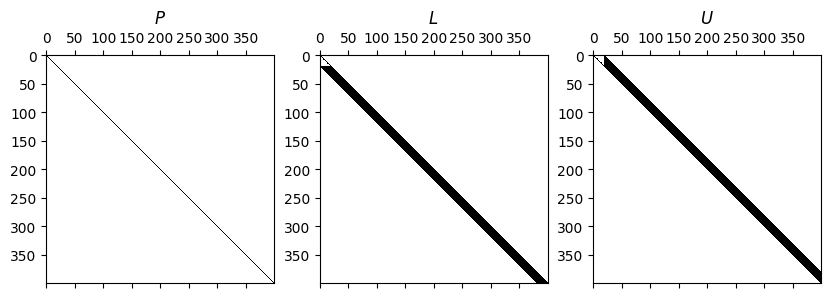

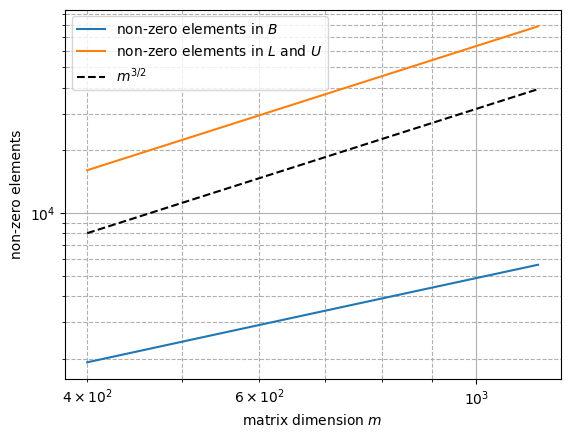

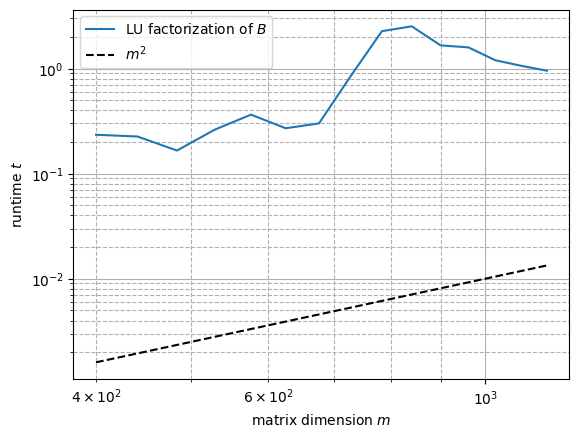

In [8]:
### BEGIN SOLUTION
B = laplacian_matrix(400)
plt.spy(B)
plt.show()

P, L, U = sp.linalg.lu(B)

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].spy(P)
ax[0].set_title("$P$")
ax[1].spy(L)
ax[1].set_title("$L$")
ax[2].spy(U)
ax[2].set_title("$U$")
plt.show()

nnz_list_B = []
nnz_list_B_LU = []
for m in m_list:
    B = laplacian_matrix(m)
    P, L, U = sp.linalg.lu(B)
    nnz_list_B.append(np.count_nonzero(B))
    nnz_list_B_LU.append(np.count_nonzero(L) + np.count_nonzero(U))

plt.loglog(m_list, nnz_list_B, label="non-zero elements in $B$")
plt.loglog(m_list, nnz_list_B_LU, label="non-zero elements in $L$ and $U$")
plt.loglog(m_list, m_list ** (3/2), ls="--", c="k", label="$m^{3/2}$")
plt.ylabel("non-zero elements")
plt.xlabel("matrix dimension $m$")
plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="--")
plt.legend()
plt.show()

t_list_B = []
for m in m_list:
    B = laplacian_matrix(m)
    t = lu_runtime(B, repeats=50)
    t_list_B.append(t)

plt.loglog(m_list, t_list_B, label="LU factorization of $B$")
plt.plot(m_list, 1e-8 * m_list ** 2, ls="--", c="k", label="$m^2$")
plt.ylabel("runtime $t$")
plt.xlabel("matrix dimension $m$")
plt.grid(True, which="major", linestyle="-")
plt.grid(True, which="minor", linestyle="--")
plt.legend()
plt.show()

# The LU factorization of a sparse matrix A often results in L and U matrices that are denser
# than A. This illustrates how factorization affects matrix sparsity, which is especially relevant
# for applications where memory and computational efficiency are key considerations.
# We notice that the computing time, which increases as m³ for the binomial case, in this case
# only increases proportionally to m². The memory consumption, which increases as m² for the
# binomial case, is here proportional to m^(3/2). This is due to the fact that the LU factorization
# of A will fill the band of the matrix, which has a width of √m. The matrices L and U therefore
# contain O(m√m) = O(m^(3/2)) non-zero elements, hence the factorization needs O(m√m²) = O(m²) operations.
### END SOLUTION

<hr style="clear:both">

## The end

Congratulations! You have made it to the end of the second exercise notebook. 